# 5.2 DSSM 双塔召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

怎样把用户与物品分别编码，使物品向量可以离线建索引，同时仍能从全库找回相关候选？

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews Books 5-core：DSSM 搜索日志不可公开时的完整电商迁移实验**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Huang et al., 2013, DSSM](https://www.microsoft.com/en-us/research/publication/learning-deep-structured-semantic-models-for-web-search-using-clickthrough-data/)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "amazon-books"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'amazon-books', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': True, 'cuda_device': 'NVIDIA RTX 6000 Ada Generation'}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 怎样把用户与物品分别编码，使物品向量可以离线建索引，同时仍能从全库找回相关候选？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

DSSM 最初解决的是 Web 搜索：query 很短，document title 较长，两边即使没有相同单词也可能表达同一概念。训练正例是搜索日志里的 query-clicked-title 对，负文档由训练候选采样；最终 NDCG 则来自人工相关性标签，不是点击率。论文真正验证的是两侧独立映射、余弦相关分、点击数据判别式训练与 letter-trigram word hashing，没有直接提出推荐系统 ANN 双塔。教程把 query/document 迁移为 user/item，把评分转成“观察正例/未观察候选”，并接 ANN；这是结构迁移，不是原论文数据或实验结论。

**来源：** [Huang et al., 2013, DSSM](https://www.microsoft.com/en-us/research/publication/learning-deep-structured-semantic-models-for-web-search-using-clickthrough-data/)

### 原文实验设计与关键结论

论文用约 1 亿 query-title 点击对训练，在 16,510 个查询、每个约 15 个带人工相关性标签的文档上报告 NDCG。Table 2 的完整 L-WH DNN 为 0.362/0.425/0.498（NDCG@1/3/10），而 TF-IDF 为 0.319/0.382/0.462。教程改用 Amazon 行为与 Recall@10，只验证从两侧编码到 Top-K 的迁移链路，不声称复现搜索 NDCG，也不把 ANN 说成原论文实验。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Amazon Reviews Books 5-core  
**资源 ID：** `amazon-books-5core`  
**切分：** per-user chronological leave-one-out  
**指标：** Recall@10, sampled NDCG@10  
**与论文比较边界：** DSSM web-search click corpus is proprietary; verify structure and retrieval protocol, not absolute NDCG

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 1 · DSSM architecture](/static/paper-figures/dssm.webp)

> **论文原图节选** · Figure 1 · DSSM architecture · PDF p.3。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **词哈希与双塔结构 Word Hashing**：把 50 万维的词袋向量按字母三元组压到 3 万维，既缩小输入又能处理训练时没见过的词（OOV）；query 与 document 两侧各走独立 DNN 编码，形成双塔。
- **多层非线性投影**：query 与每个 document 各走 3 层全连接（30k→300→300→128），把稀疏特征压到 128 维语义空间。
- **余弦 + Softmax**：双塔只在最后做相似度计算，物品侧 128 维向量可以离线算出并建 ANN 索引；同一批内其他 item 自然充当负样本。

### 结构：两条独立编码路径

先按原论文读图：底部是高维稀疏输入，中间是逐层变窄的非线性投影，顶部是 128 维语义向量；query 与多个 document 直到余弦相似度处才相遇。推荐迁移后，用户特征 $x_u$ 进入用户塔 $f_\theta$，物品特征 $x_i$ 进入物品塔 $g_\phi$。两座塔可以有不同输入，但最后都输出同样的 $d$ 维向量。

| 符号 | 含义 | 形状 |
|---|---|---|
| $B$ | 一次训练的用户数 | 标量 |
| $N$ | 参与比较的物品数 | 标量 |
| $d$ | 公共向量空间维度 | 标量 |
| $U$ | 一批用户向量 | $[B,d]$ |
| $V$ | 物品向量库 | $[N,d]$ |

因此 $UV^\top$ 的第 $(b,n)$ 个格子正好是第 b 个用户和第 n 个物品的点积，一次矩阵乘法得到 $[B,N]$ 个分数。

```text
x_u -> Embedding/MLP -> u --\
                              dot product -> score -> sampled loss
x_i -> Embedding/MLP -> v --/
```

### 从相似度到训练目标

向量长度 $\|u\|_2=\sqrt{u_1^2+\cdots+u_d^2}$。先做归一化 $\bar u=u/\|u\|_2,\ \bar v=v/\|v\|_2$，两支箭头长度都变成 1，于是 $s(u,i)=\bar u^\top\bar v$ 就等于余弦并落在 $[-1,1]$。对一个正物品 $i^+$ 和若干负物品 $i^-$，温度（temperature）$\tau$ 控制分布尖锐程度：

$$P(i^+|u)=\frac{\exp(s(u,i^+)/\tau)}{\sum_{j\in\{i^+,i^-\}}\exp(s(u,j)/\tau)},\qquad L=-\log P(i^+|u).$$

把 $-\log$ 想成“答错惩罚”：若正确物品概率为 0.9，损失约 0.105；若只有 0.1，损失约 2.303。正物品分数上升会增大分子占比并降低损失。独立物品塔使 $v$ 能离线计算并建立 ANN 索引；这一步是推荐工程迁移，不是 DSSM 论文的 ANN 实验。

### 公式到代码

`run_dssm` 负责构造正负对、调用 Torch-RecHub DSSM、反向传播并做全库 Top-K；数据加载与时间切分在源码讲解页逐函数展开。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [隐式反馈、正例与未知项](/notebooks/3_2_data_ml_basics#implicit-feedback)
- [向量、点积与余弦](/notebooks/3_3_linear_algebra#elementwise-dot)
- [Softmax、温度与归一化](/notebooks/3_6_information_theory#softmax-temperature)
- [多类交叉熵](/notebooks/3_6_information_theory#cross-entropy-kl)

### 本论文新增数学（本节详细推导）

两侧独立编码、点击对中的负文档采样，以及把余弦分数变成条件概率；ANN 是推荐迁移后的工程接口，不是 DSSM 原论文实验。

先把 $u$、$v$ 想成两支从原点出发的箭头。点积 $u^\top v$ 同时受方向和长度影响；除以两者长度后，$\cos(u,v)=u^\top v/(\|u\|_2\|v\|_2)$ 只比较方向。若归一化后的用户为 $(0.8,0.6)$，物品 A 为 $(0.9,0.4)$、物品 B 为 $(-0.2,0.9)$，就分别代入“横坐标乘横坐标 + 纵坐标乘纵坐标”。批量计算时，$[B,d]$ 乘 $[N,d]^\top$ 只是一次同时完成 $B\times N$ 组点积，输出 $[B,N]$。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

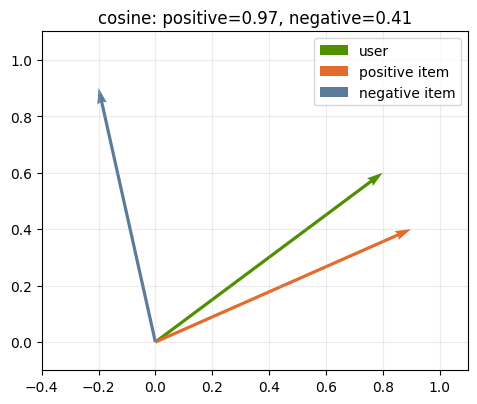

{'user@positive': np.float64(0.975), 'user@negative': np.float64(0.412)}


In [2]:
import numpy as np, matplotlib.pyplot as plt
user=np.array([.8,.6]); positive=np.array([.9,.4]); negative=np.array([-.2,.9])
norm=lambda x:x/np.linalg.norm(x)
scores=[norm(user)@norm(v) for v in [positive,negative]]
fig,ax=plt.subplots(figsize=(5.5,4.4))
for vector,label,color in [(user,'user','#4f8f00'),(positive,'positive item','#e36b2c'),(negative,'negative item','#5b7c99')]:
    ax.quiver(0,0,*vector,angles='xy',scale_units='xy',scale=1,label=label,color=color)
ax.set(xlim=(-.4,1.1),ylim=(-.1,1.1),title=f'cosine: positive={scores[0]:.2f}, negative={scores[1]:.2f}')
ax.grid(alpha=.25); ax.legend(); plt.show()
print({'user@positive':round(scores[0],3),'user@negative':round(scores[1],3)})

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** Amazon Reviews Books 5-core  
**资源 ID：** `amazon-books-5core`  
**切分：** per-user chronological leave-one-out  
**指标：** Recall@10, sampled NDCG@10  
**与论文比较边界：** DSSM web-search click corpus is proprietary; verify structure and retrieval protocol, not absolute NDCG

### smoke 教学适配器（默认 runner 实际读取）

仓库随附的真实 Amazon 评分教学子集；`rating>=4` 仅在这个迁移实验中定义为正反馈，按时间切出训练/测试并按用户留出最后正例。它没有曝光日志，未评分物品只能称为“未观察”，不能称为论文里的未点击文档。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.matching.DSSM。full profile 映射 TorchEasyRec 双塔配置，并把 item tower 导出到 Faiss、HNSW 或 Milvus。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.5_2_dssm.train")
run_dssm = chapter_train.run_dssm

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_dssm))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_dssm(epochs: int = 24, *, progress: ProgressCallback | None = None) -> dict:
    # 1) 固定参数初始化，并读取本章指定的真实数据切片。
    emit_progress(progress, stage="data_prepare", current=0, total=1, message="加载并切分 DSSM 数据")
    seed_everything(); device = training_device(); ratings, provenance = _real_amazon()
    events = complete_or_recent(ratings, 5200).reset_index(drop=True)
    split = int(len(events) * .8)
    train, test = events.iloc[:split], events.iloc[split:]
    n_users, n_items = ratings.user_id.nunique(), ratings.item_id.nunique()
    user_features = [SparseFeature("user_id", n_users + 1, 16, padding_idx=0)]
    item_features = [SparseFeature("item_id", n_items + 1, 16, padding_idx=0)]
    tower = {"dims": [32, 16], "activation": "relu", "dropout": 0.0}
    # 2) 按论文结构实例化模型；这里是理解层尺寸和特征契约的入口。
    model = DSSM(user_features, item_features, tower, tower, temperature=.12)
    model.to(device)

    def fields(frame):
        return {
            "user_id": torch.t

## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_dssm(progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载并切分 DSSM 数据


[data_prepare] 1/1 test_rows=1040 train_rows=4160


[train] 0/48 starting


[train] 3/48 epoch 2/24 batch_loss=0.609967


[train] 6/48 epoch 3/24 batch_loss=0.504954


...

[inference] 2/3


[inference] 3/3


[evaluate] 0/1 计算采样排序指标


[evaluate] 1/1 recall@10=0


{'framework': 'torch_rechub.models.matching.DSSM', 'dataset': {'dataset': 'Amazon Reviews 2023 / Video Games / 5-core', 'source': 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/benchmark/5core/rating_only/Video_Games.csv.gz', 'source_sha256': 'a2bde5f3b945960d161538c200dd87845e6ee471b46da96410dde61613c6901c', 'slice_rule': 'top 500 users by observed interaction count; ties by user_id; all their rows retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/amazon-reviews-2023-video-games/interactions.csv', 'rows_used': 16172, 'users_used': 128, 'items_used': 7392, 'time_min_utc': '2000-09-17T21:55:58+00:00', 'time_max_utc': '2023-05-31T16:03:41+00:00', 'positive_rule': 'observed Amazon rating >= 4.0', 'randomly_fabricated_rows': 0, 'train_rows': 4160, 'test_rows': 1040, 'label': 'observed Amazon rating >= 4.0'}, 'device': None, 'validation_mode': None}
inference contract: 用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。
loss: 0.6133 → 0.517


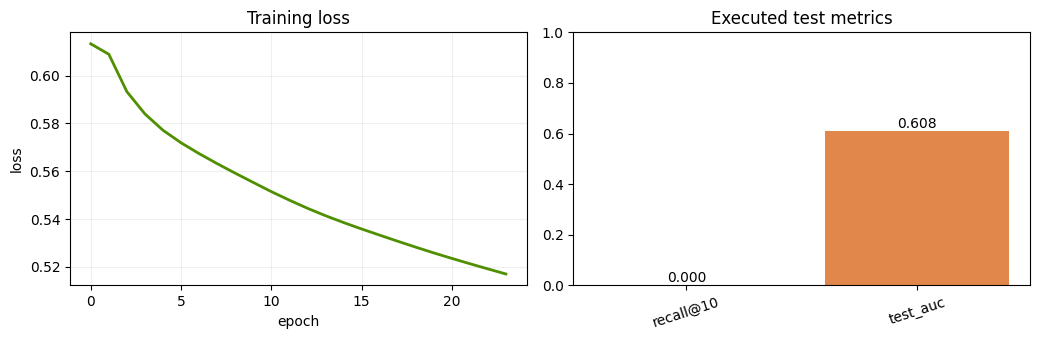

,value
recall@10,0.000000
test_auc,0.608445


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'recall@10': result['recall@10'], 'test_auc': result['test_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Amazon Reviews Books 5-core", "resource": "amazon-books-5core", "split": "per-user chronological leave-one-out", "metrics": ["Recall@10", "sampled NDCG@10"], "paper_comparison": "DSSM web-search click corpus is proprietary; verify structure and retrieval protocol, not absolute NDCG"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 recall@10 = **{result['recall@10']:.4f}**。
- 辅助指标 test_auc = **{result['test_auc']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** Amazon review 仍是主动评分而非完整曝光日志；它比电影评分更接近电商目录与冷启动，但 Recall 仍不能直接代表线上曝光收益。

### 工业边界

用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 recall@10 = **0.0000**。
- 辅助指标 test_auc = **0.6084**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **0.6133** 降到 **0.5170**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** Amazon review 仍是主动评分而非完整曝光日志；它比电影评分更接近电商目录与冷启动，但 Recall 仍不能直接代表线上曝光收益。

### 工业边界

用户塔在线编码 → L2 归一化 → ANN Top-K；物品塔离线批量更新。监控索引新鲜度、负采样分布与向量范数。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'DSSM 双塔召回',
    'primary_metric': 'recall@10', 'primary_value': float(result['recall@10']),
    'secondary_metric': 'test_auc', 'secondary_value': float(result['test_auc']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '5_2_dssm',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_5','5_2_dssm',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_5/5_2_dssm.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['recall@10']) <= 1
assert np.isfinite(float(result['test_auc']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。